In [1]:
import csv
import matplotlib.pyplot as plt
import math
import numpy as np
import time
import os

In [2]:
def read_custom_csv(file_path):
    """ Read a csv file and store in a dictionary each category"""

    data = {}
    current_title = None

    categories = ["EC-cones", "IC-cones", "F-cones", "EC-points", "IC-points","MC-points", "True-MidPoints"]

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip() # Remove non desired white spaces
            if line in categories:
                current_title = line
                data[current_title] = []
            else:
                x, y = map(float, line.split(',')) # Convert to float and separate by comma
                data[current_title].append((x, y))

    return data


def plot_points(points, points2=None, points3=None, infL=-25, upL=120):

    # Definir los límites del eje
    plt.xlim(infL, upL)
    plt.ylim(infL, upL)

    x1 = [point[0] for point in points]
    y1 = [point[1] for point in points]
    plt.scatter(x1, y1)

    if points2 is not None:
        x2 = [point[0] for point in points2]
        y2 = [point[1] for point in points2]
        plt.scatter(x2, y2)

        if points3 is not None:
            x3 = [point[0] for point in points3]
            y3 = [point[1] for point in points3]
            plt.scatter(x3, y3)

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Bird\'s Eye View')
    #plt.gca().invert_yaxis()  # Invert y-axis to match typical BEV representation
    plt.show()

def write_to_csv(filename, data):
    with open(filename, 'w', newline='') as csvfile:
        fieldnames = ['iteration_index', 'x', 'y']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for row in data:
            writer.writerow({
                'iteration_index': row['iteration_index'],
                'x': row['x'],
                #'cones': [';'.join([f'({x},{y})' for x, y in row['cones']])]
                'y' : row['y']
            })

In [3]:
def distance(point1, point2):
    return math.sqrt((point2[0] - point1[0])**2 + (point2[1] - point1[1])**2)

def are_perpendicular(v1, v2):
    dot_product = np.dot(v1, v2)
    return np.isclose(dot_product, 0)

def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in degrees between vectors 'v1' and 'v2'.
    Angle is returned in the range [0,180], which means that does not distinguish between counter/clockwise.
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return 180 * np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)) / np.pi

# Function to draw the semicircle
def draw_semicircle(p1, p2, dp, cones, radius=30):

    # Draw circle with radius dp
    circle = plt.Circle(p1, radius, color='b', fill=False)
    plt.gca().add_patch(circle)
    
    # Draw line from midpoint perpendicular to dp
    dperp1 = np.array([dp[1], -dp[0]])
    x_perpendicular = [p1[0], p1[0] + dperp1[0]]
    y_perpendicular = [p1[1], p1[1] + dperp1[1]]
    plt.plot(x_perpendicular, y_perpendicular, color='r')

    dperp2 = np.array([-dp[1], dp[0]])
    x_perpendicular2 = [p1[0], p1[0] + dperp2[0]]
    y_perpendicular2 = [p1[1], p1[1] + dperp2[1]]
    plt.plot(x_perpendicular2, y_perpendicular2, color='r')
    
    # Plot vector dp
    x_dist = [p1[0], p1[0] + dp[0]]
    y_dist = [p1[1], p1[1] + dp[1]]
    plt.plot(x_dist, y_dist)

    assert (are_perpendicular(np.array(dp), dperp1))
    assert (are_perpendicular(np.array(dp), dperp2))
    
    # Plot points p1 and p2
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'ro')

    points_within_semicircle = []
    for cone in cones:
        dist_vect = np.array(cone) - np.array(p1)

        if 0<=angle_between(dp,dist_vect)<=90 and distance(cone,p1)<= radius:
            points_within_semicircle.append(cone)
    
    return points_within_semicircle


def main(cones, midpoints):
    result = []
    midpoints.append(midpoints[0]) # To close the bucle
    for i in range(len(midpoints)-1):
        data_it = {}
        points_within_semicircle = []
        current_point = midpoints[i]
        next_point = midpoints[i + 1]
        dp = np.array(next_point) - np.array(current_point)
        points_within_semicircle = draw_semicircle(current_point,next_point,dp, cones)
        data_it = {"iteration_index": i, "x": current_point[0], "y": current_point[1]}
        result.append(data_it)
        for point in points_within_semicircle:
            # Do not repeat the same point
            if point[0]!=current_point[0] and point[1]!=current_point[1]:
                data_it = {"iteration_index": i, "x": point[0], "y": point[1]}
                result.append(data_it)
        plot_points([current_point, next_point], cones, points_within_semicircle)
        time.sleep(1)
    return result

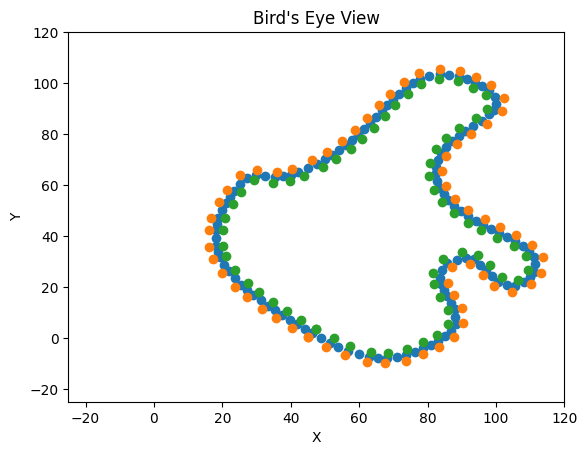

In [4]:
csv_path = "./tilke_circuits_GT/TILKE_1.csv"
data = read_custom_csv(csv_path)
cones_ExtC = data["EC-cones"]
cones_IntC = data["IC-cones"] 
mid_points = data["True-MidPoints"]
plot_points(mid_points, cones_ExtC, cones_IntC)

In [5]:
# Specify the path to CSV files within the subfolder
folder_path = './tilke_circuits_GT/'
output_folder_path = './tilke_database_2/'
# Get and store all files
file_list = os.listdir(folder_path)
csv_files = [file for file in file_list if file.endswith(".csv")]

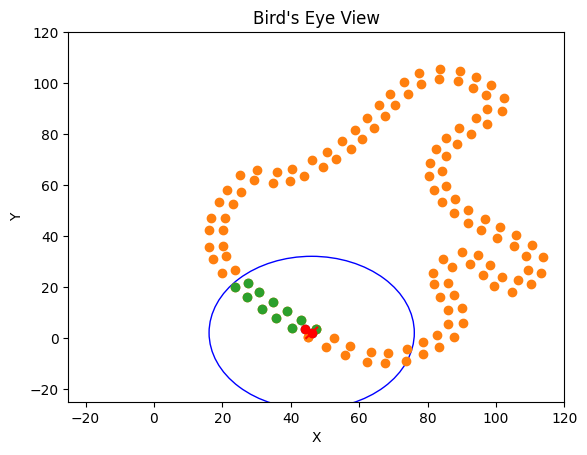

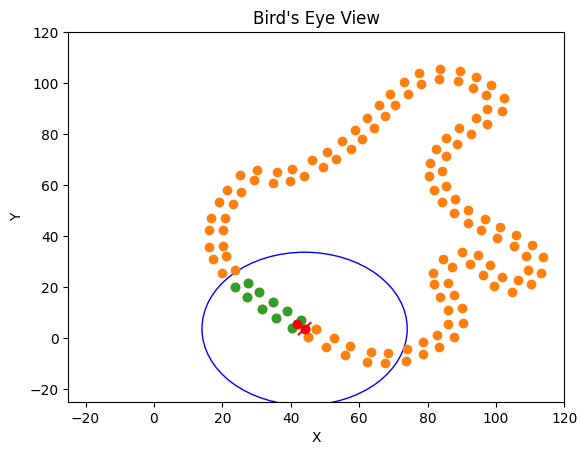

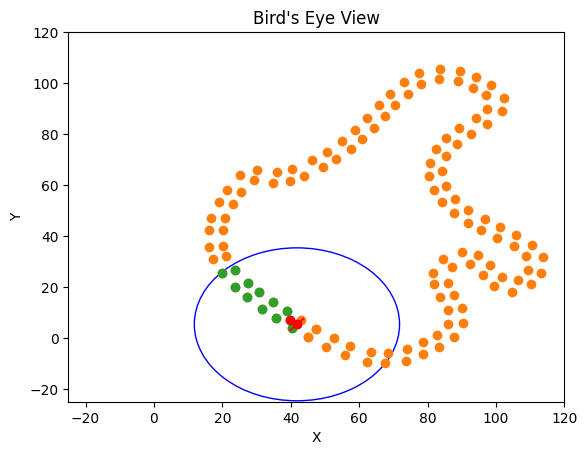

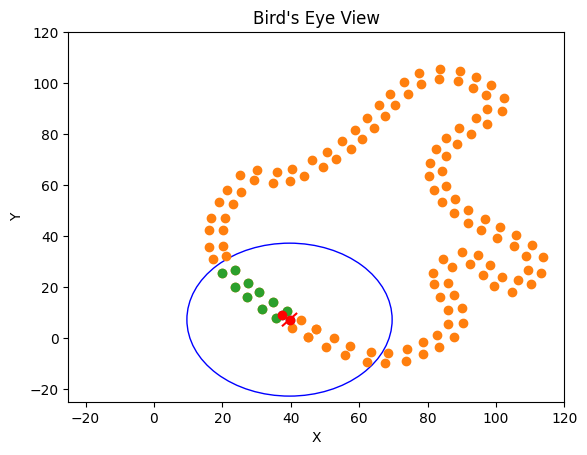

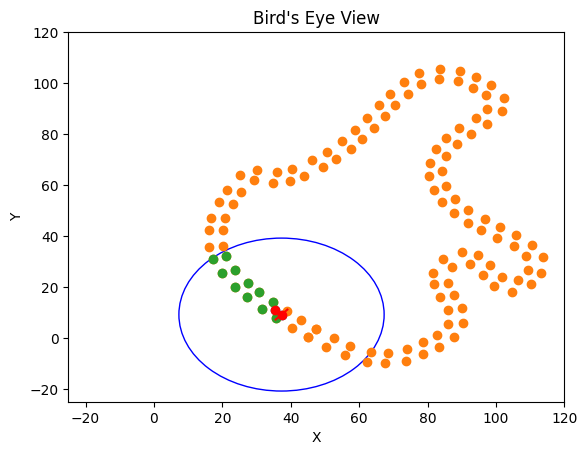

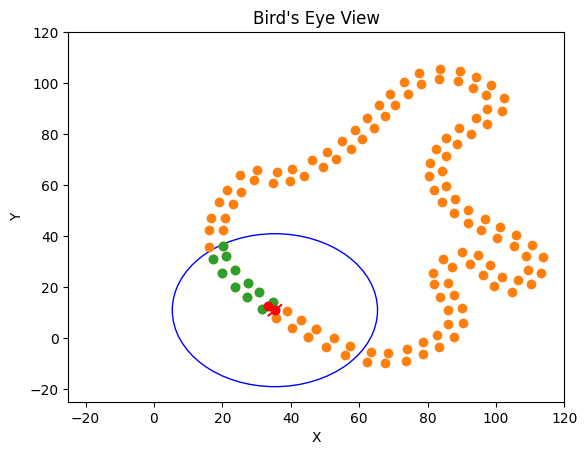

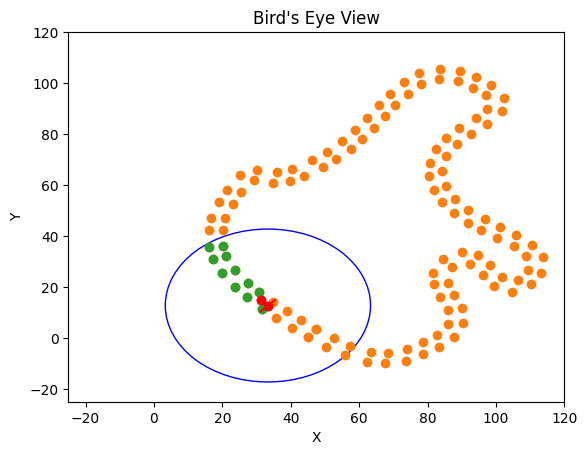

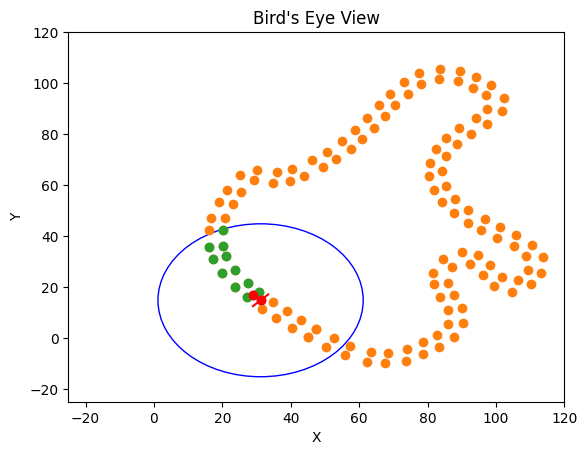

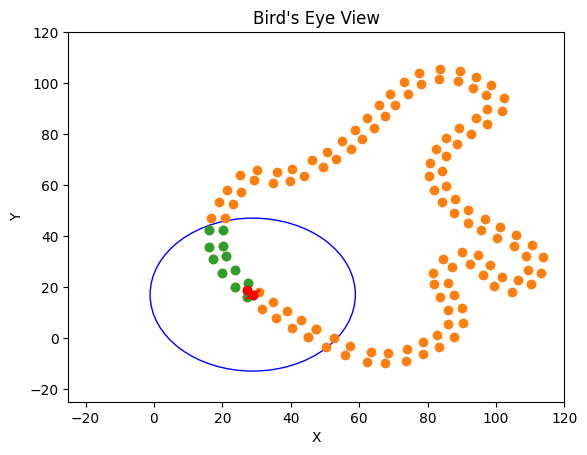

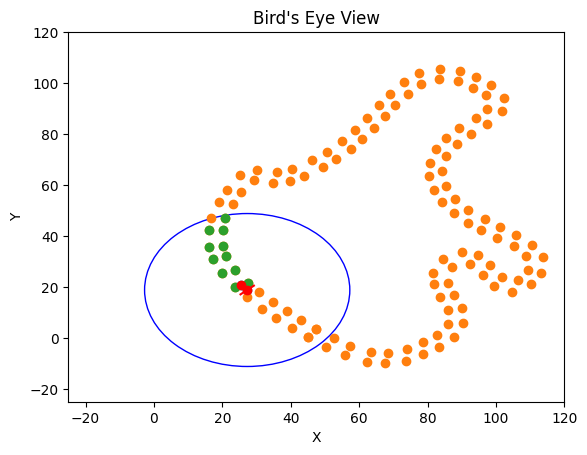

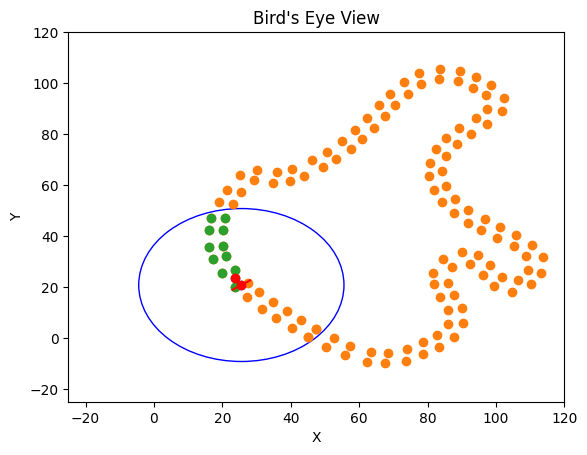

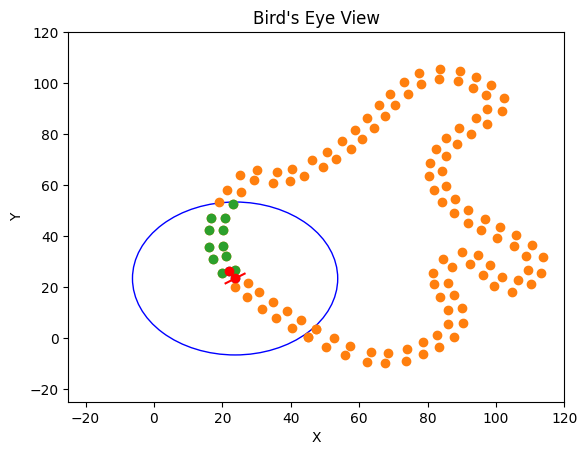

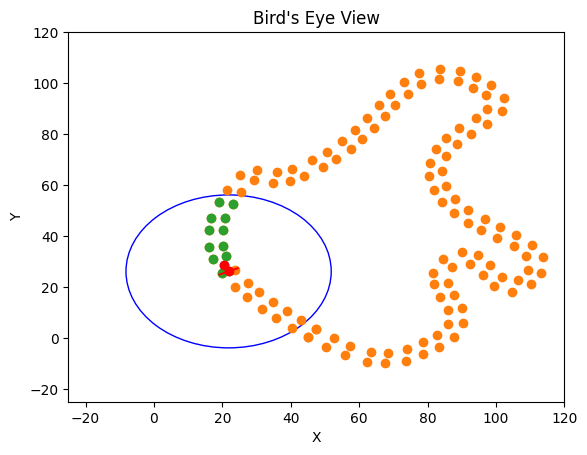

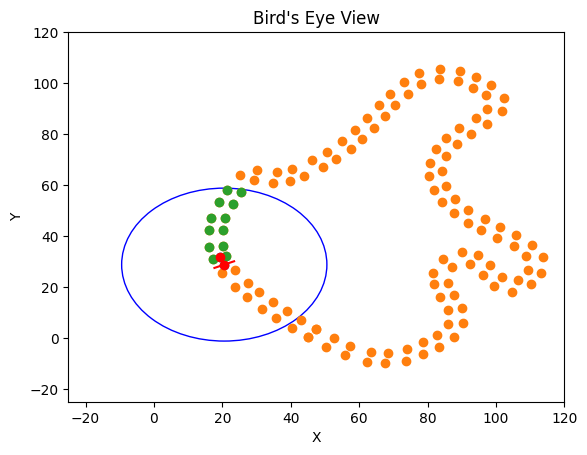

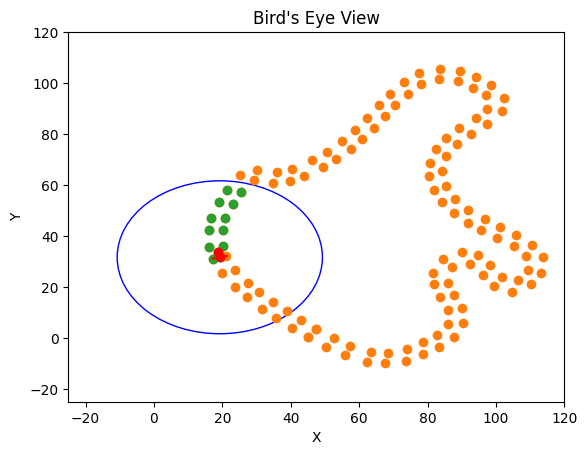

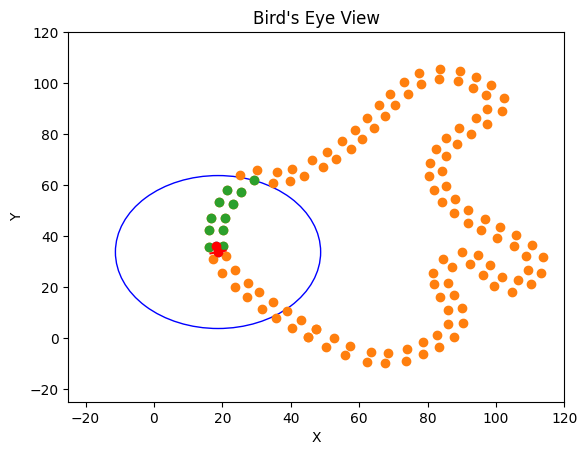

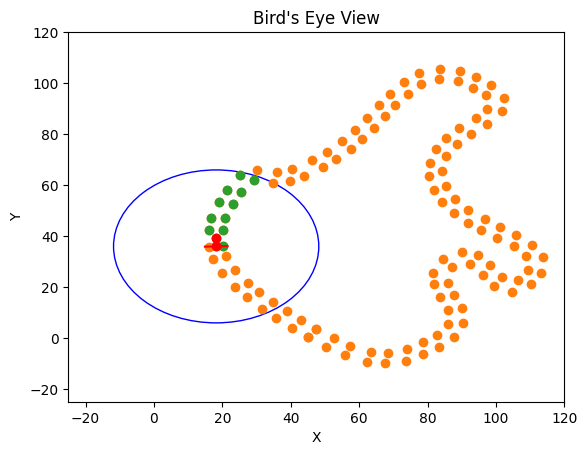

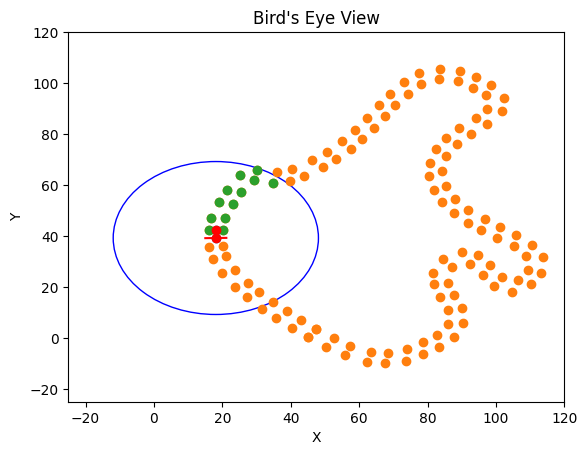

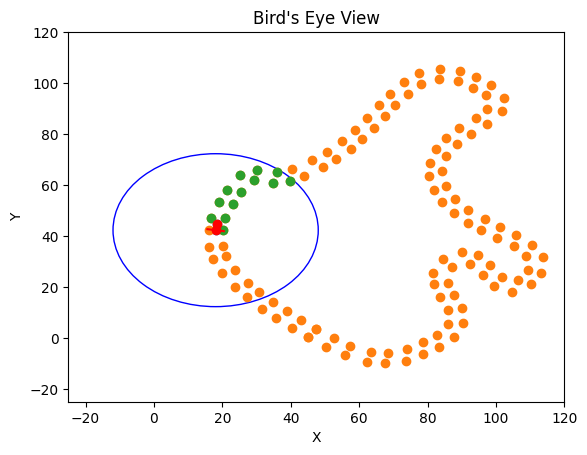

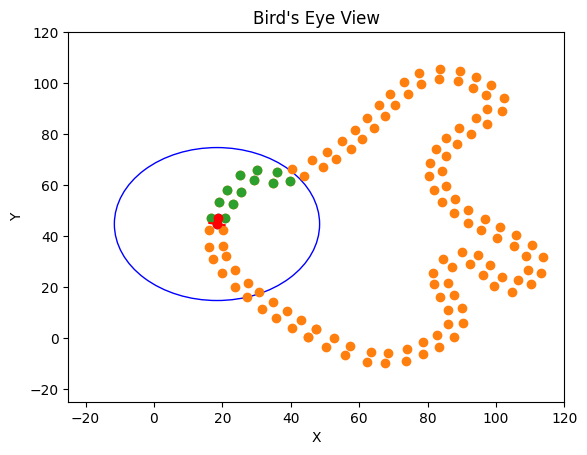

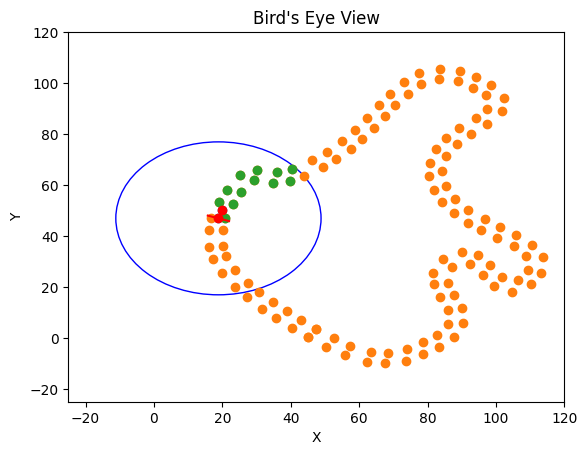

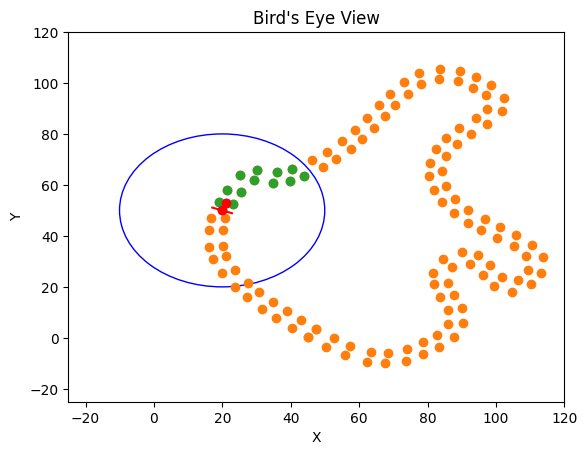

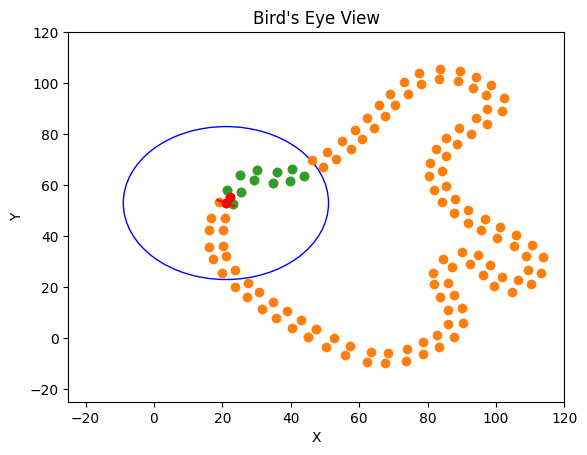

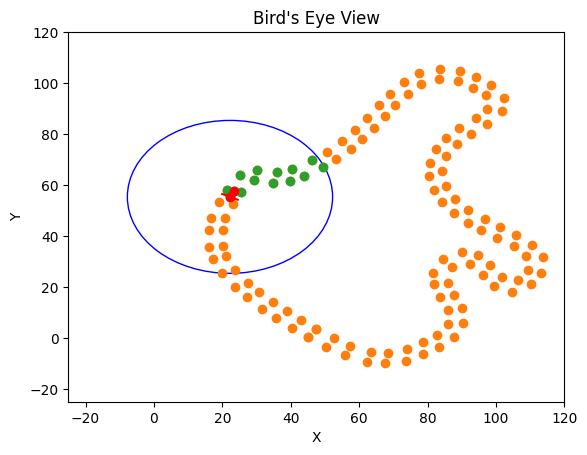

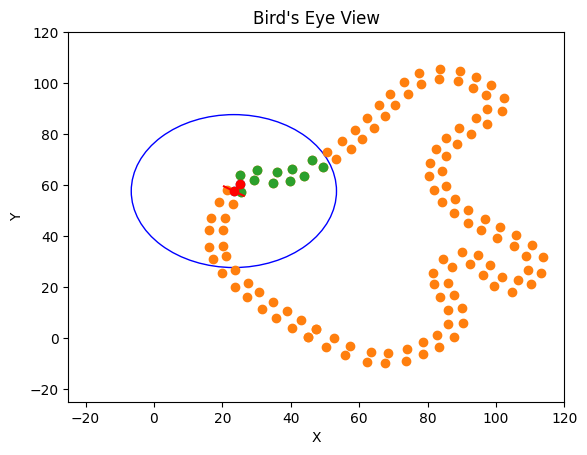

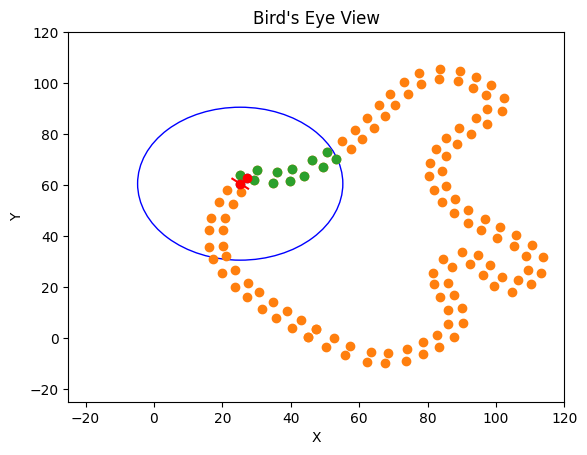

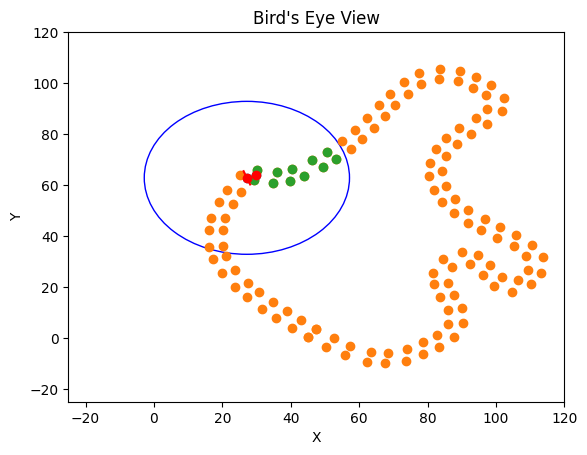

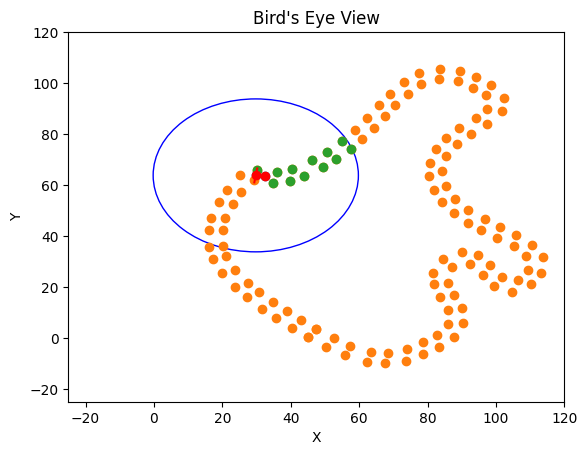

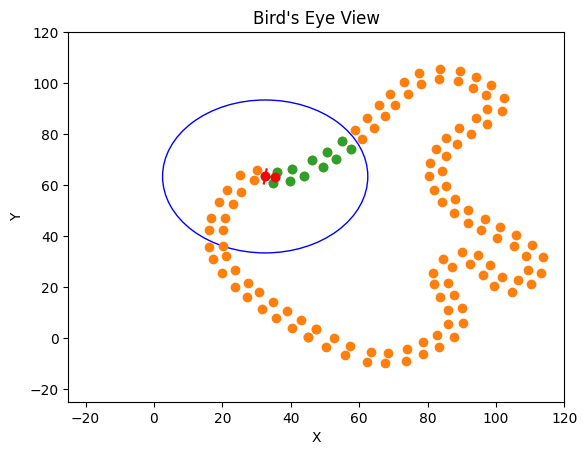

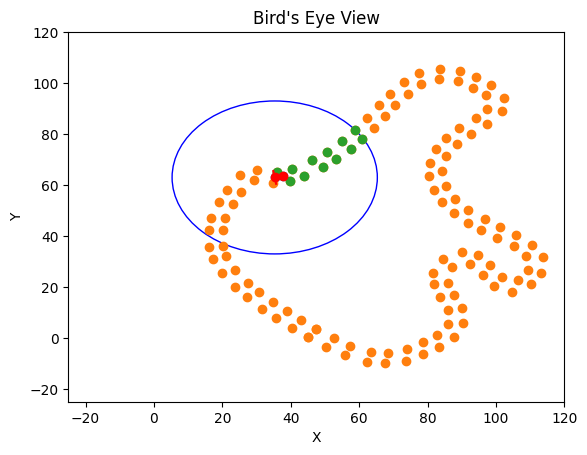

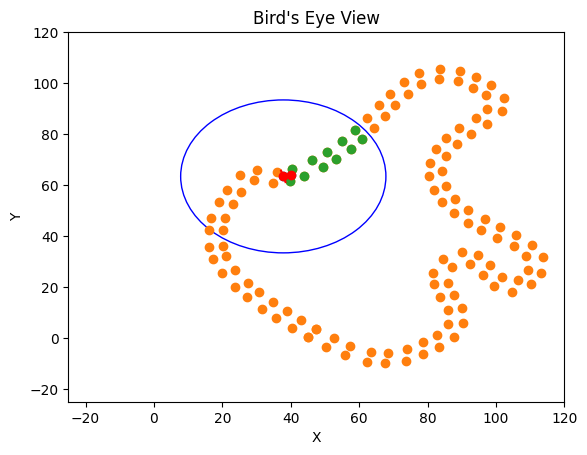

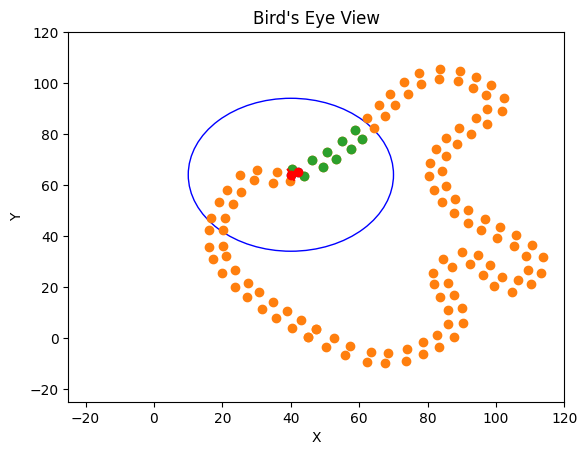

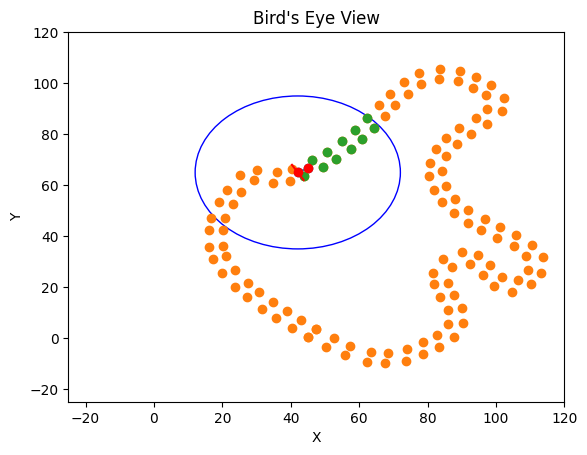

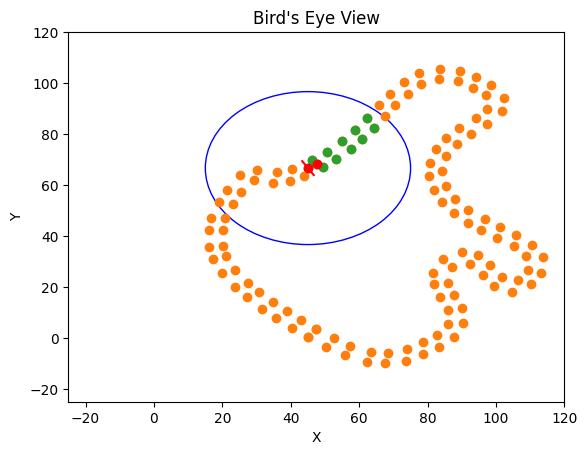

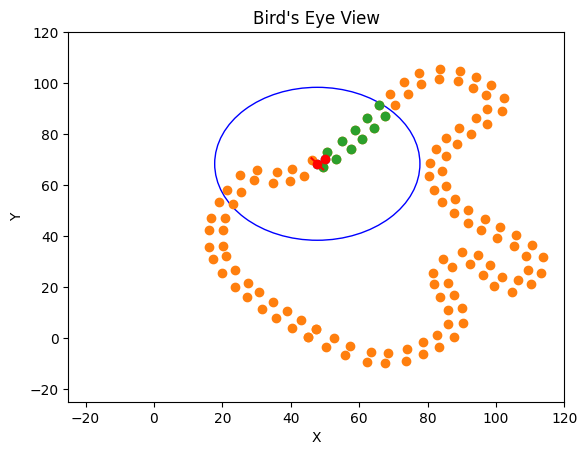

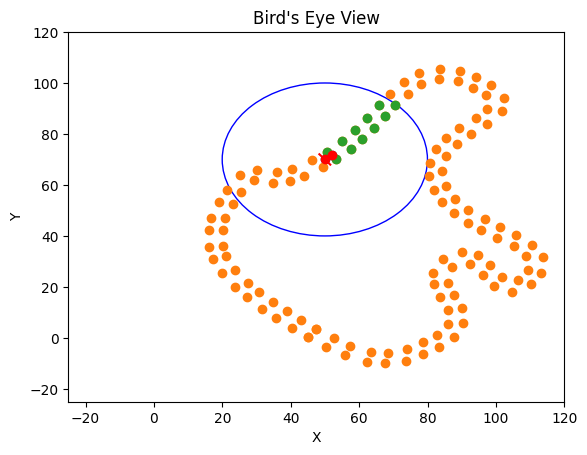

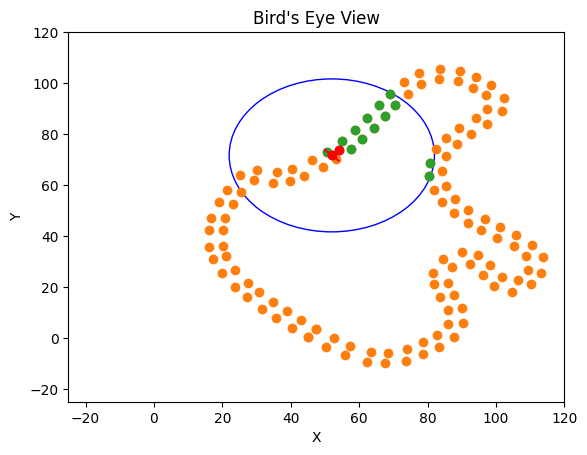

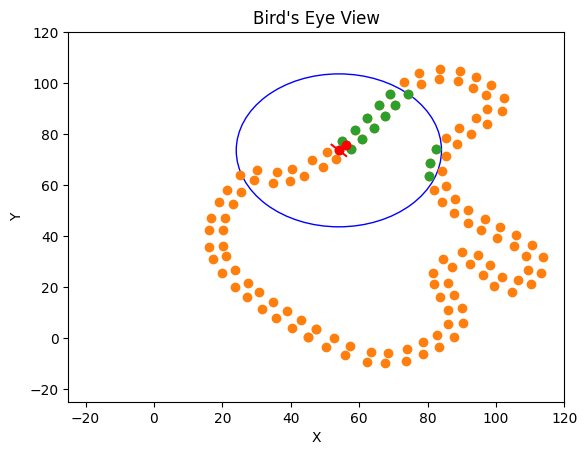

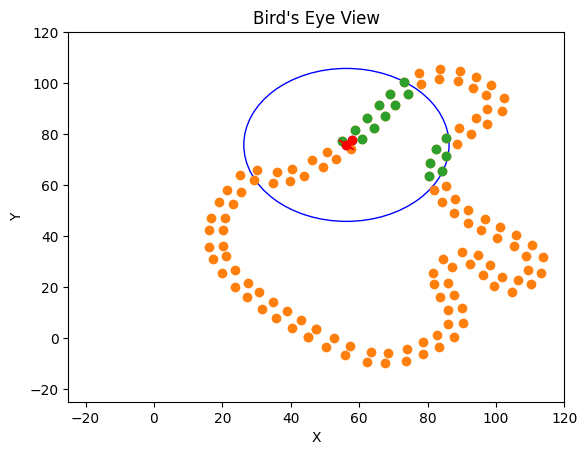

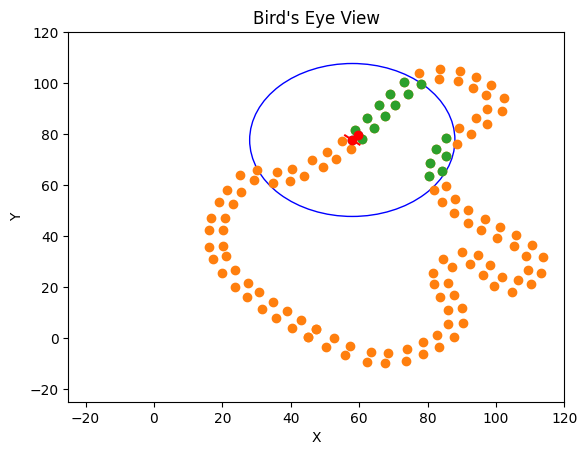

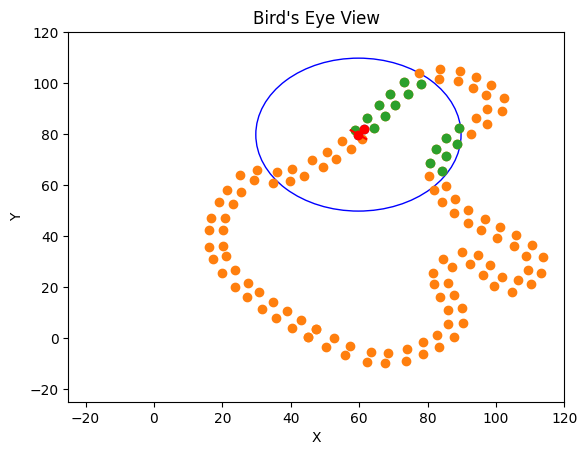

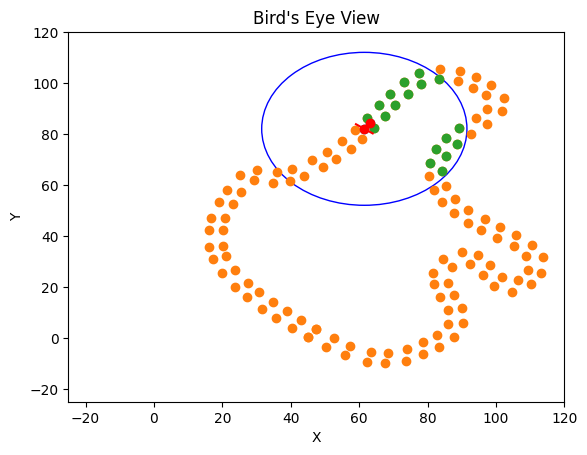

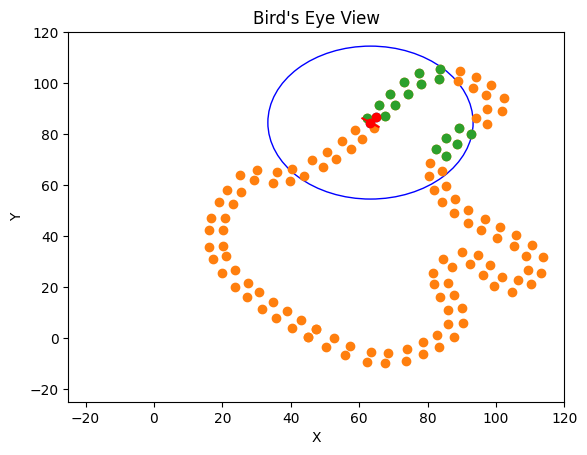

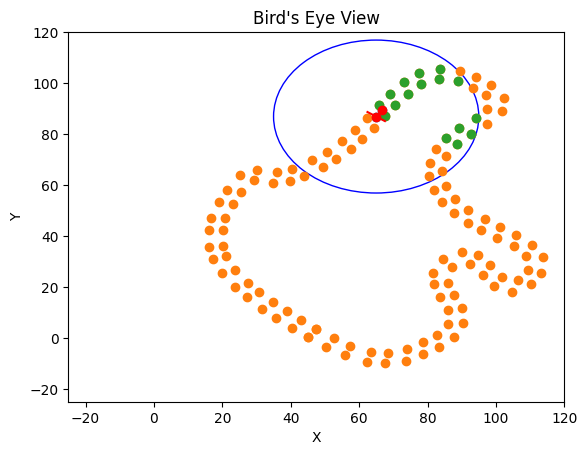

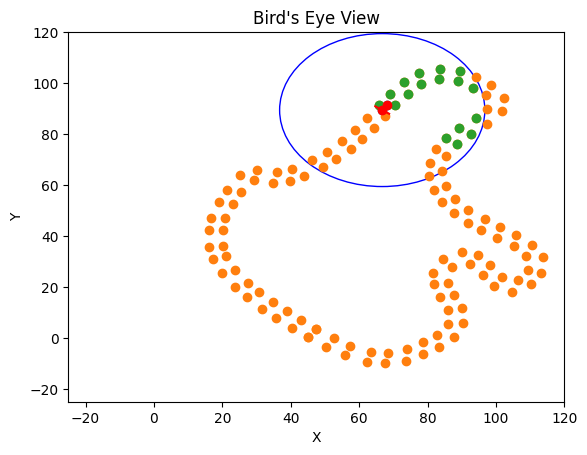

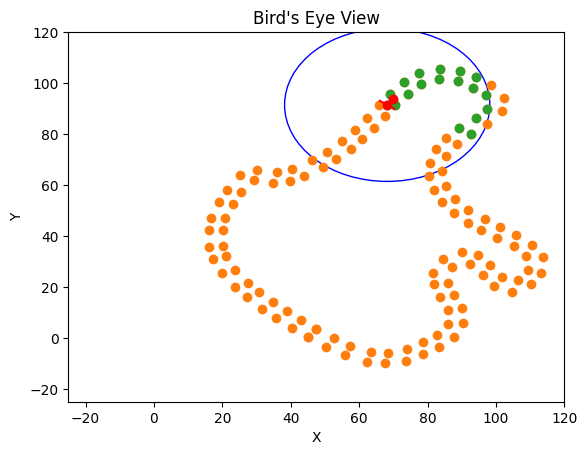

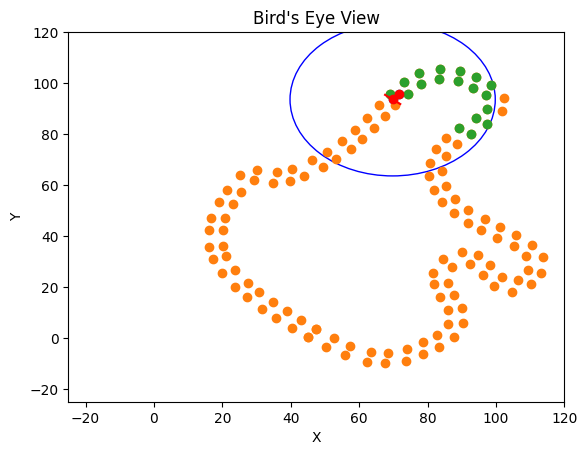

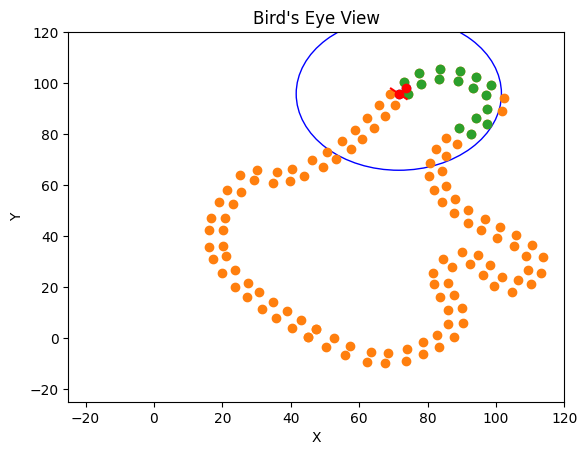

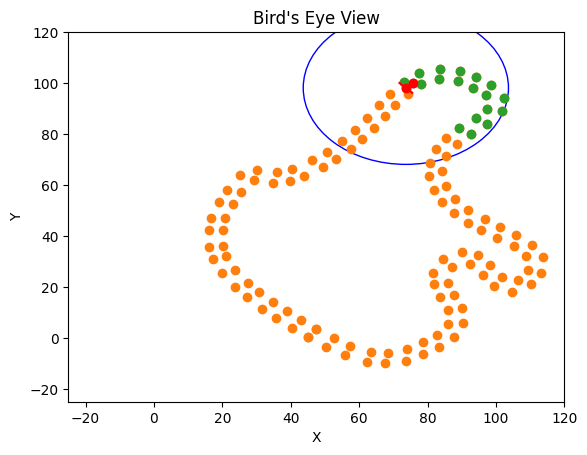

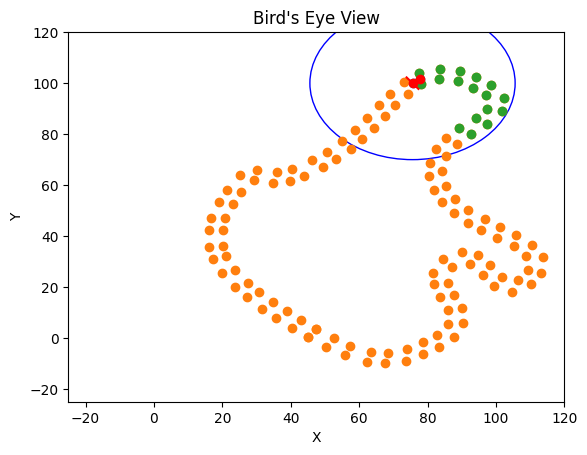

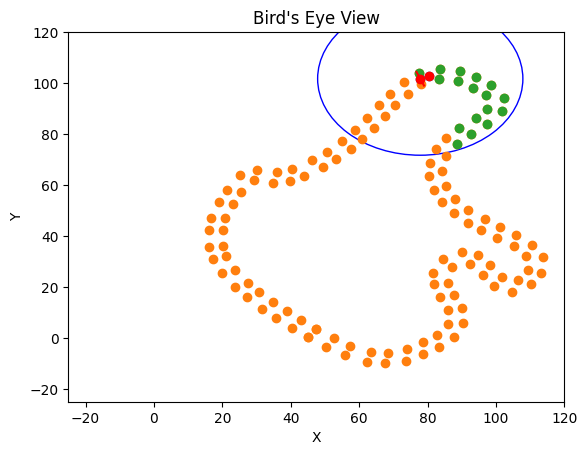

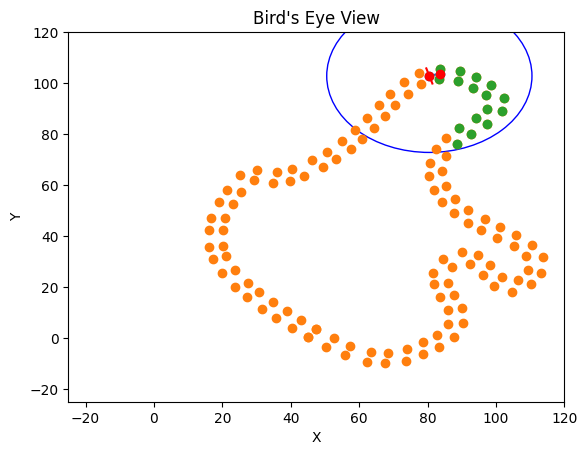

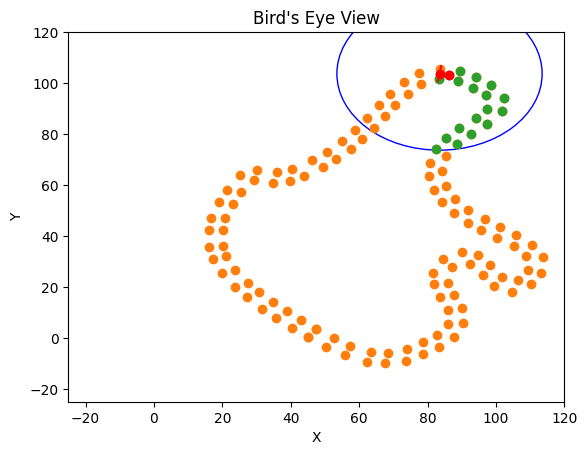

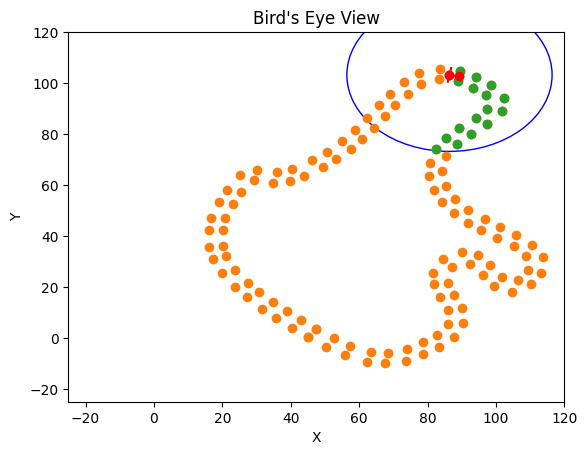

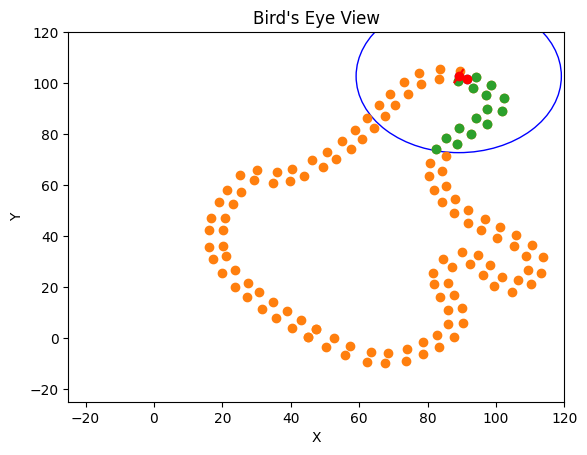

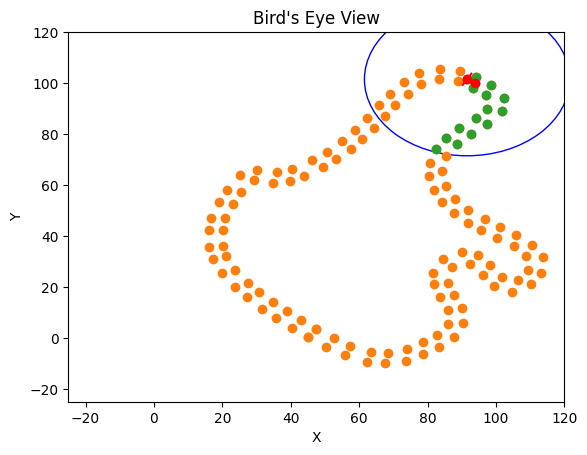

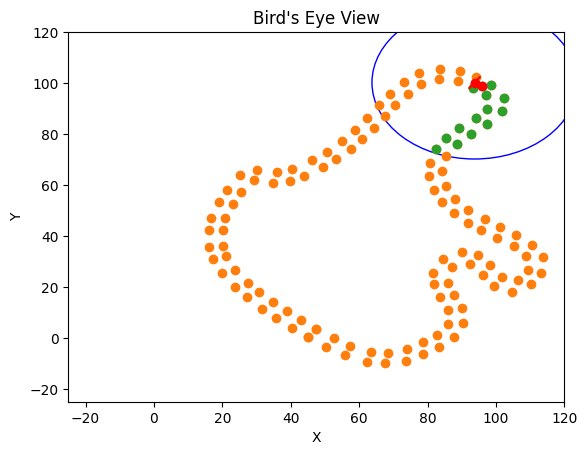

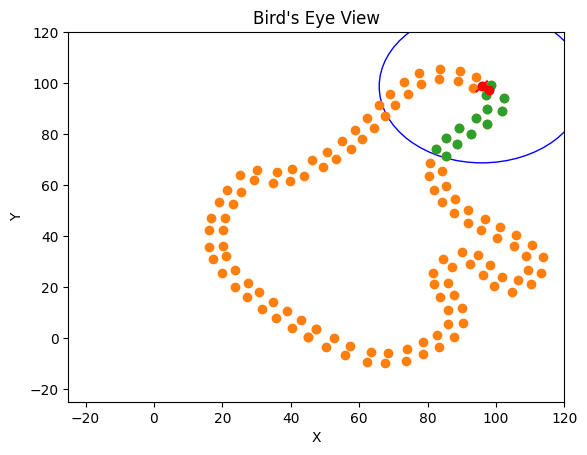

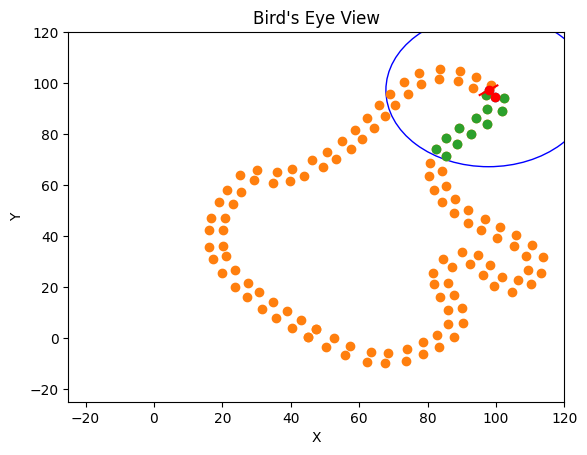

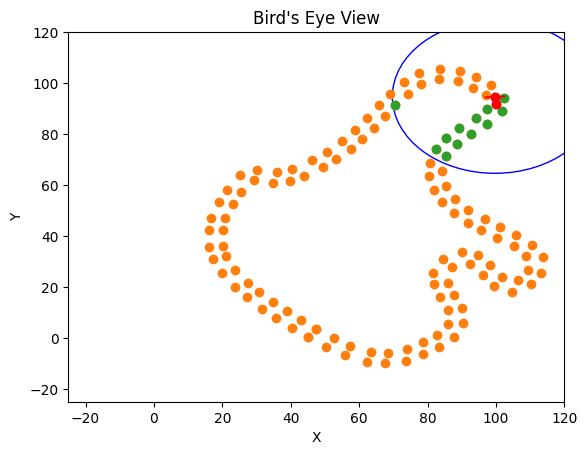

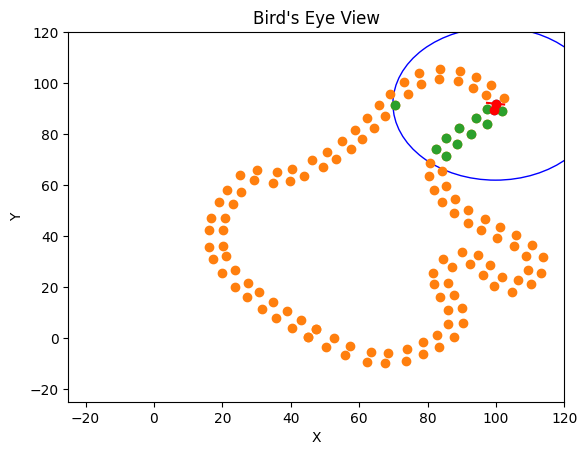

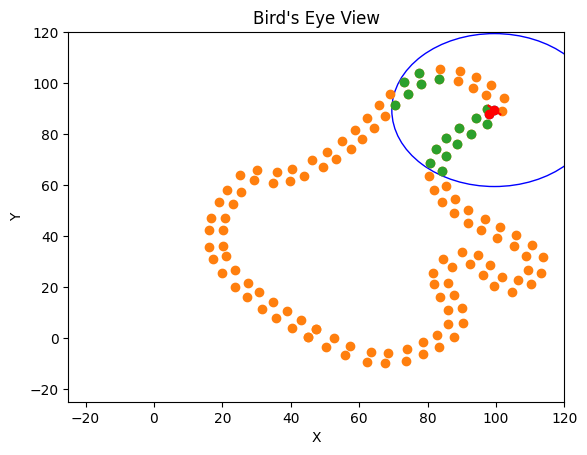

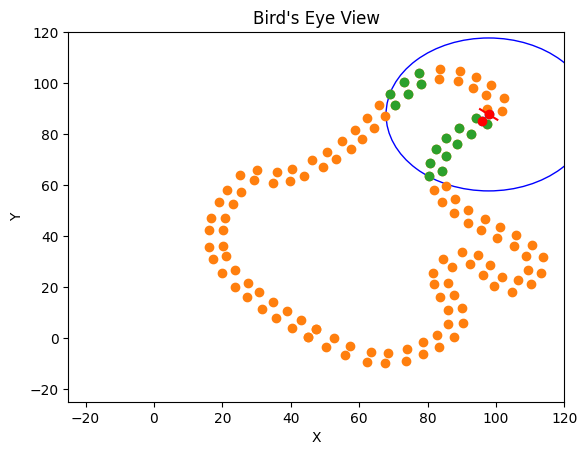

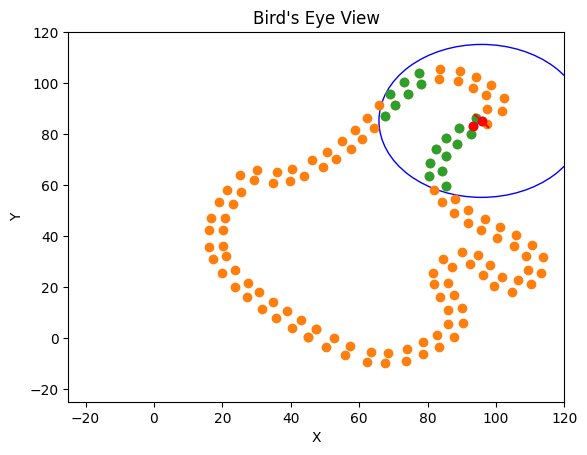

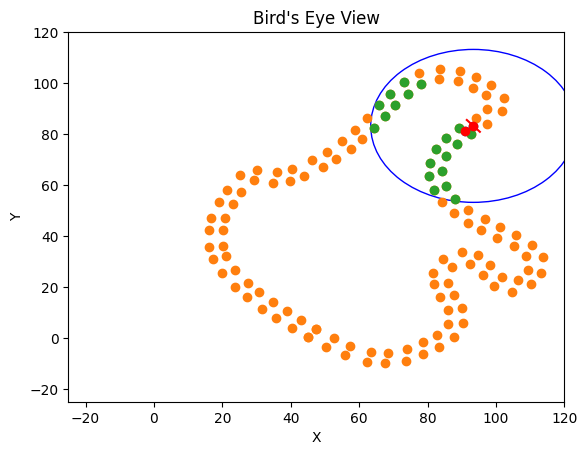

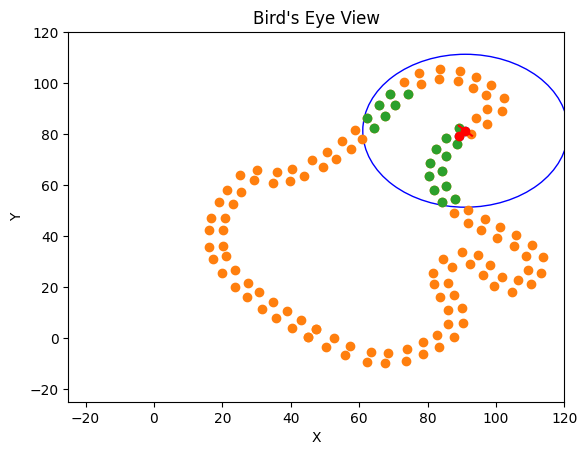

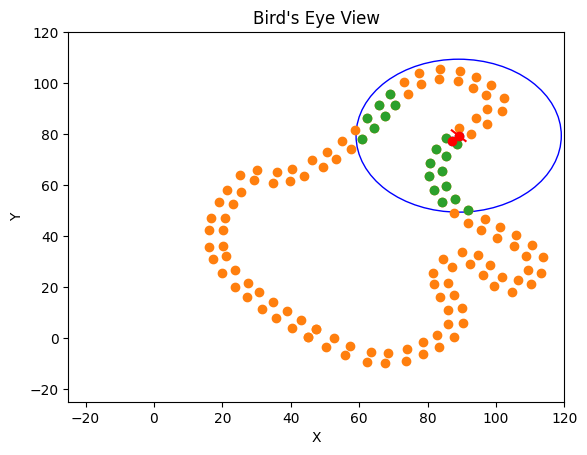

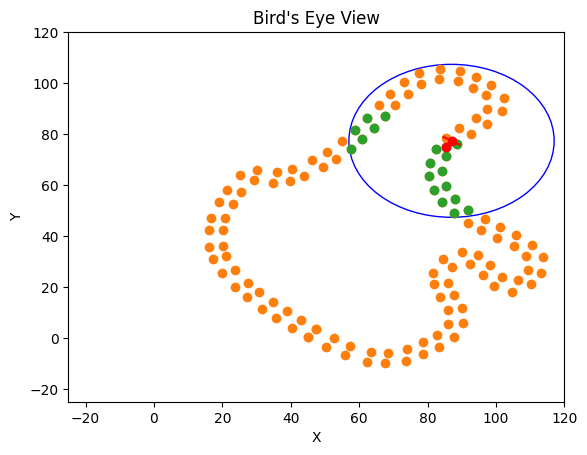

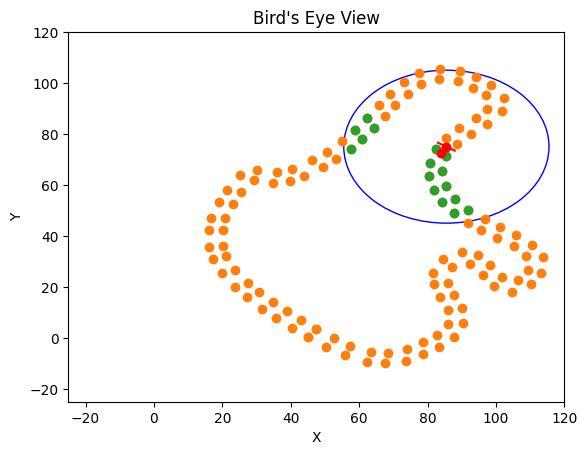

KeyboardInterrupt: 

In [7]:
# Keep track of progress
num_circuits_to_process = len(csv_files)
num_circuits_processed = 0

for csv_file in csv_files:
    csv_path = folder_path+csv_file
    data = read_custom_csv(csv_path)
    cones_ExtC = data["EC-cones"]
    cones_IntC = data["IC-cones"] 
    mid_points = data["True-MidPoints"]
    cones = cones_ExtC + cones_IntC
    
    result = main(cones, mid_points)
    #write_to_csv(output_folder_path + csv_file, result)

# Keep track of progress
    num_circuits_processed += 1
    print("Progress : ", 100 * num_circuits_processed/ num_circuits_to_process)